In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from functools import partial
from ciceroscm import input_handler

from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter


In [ ]:
cscm_data_dir = "../src/meteor/default_scm_data"


In [ ]:
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp245"], dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP'])
models = data_getter.models
models = ["CanESM5", "IPSL-CM6A-LR"]
flds = ["tas", "pr"]

#For predictions: 
conc_data = input_handler.read_inputfile(
    os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
)
ih = input_handler.InputHandler({})
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

In [ ]:
em_data_ghg=em_data.copy()
em_data_aer=em_data.copy()

In [ ]:
em_data_ghg['SO2']=0


In [ ]:
models

In [ ]:
train_data=data_getter.make_meteor_training_data

In [ ]:
tmp=partial(train_data, model='CanESM5')

In [ ]:
data_getter.exps

In [ ]:
local_data={}
exp_list=["base", "co2x4"]
for i, model in enumerate(models):
    local_data[model]={}
    tmp=partial(train_data, model=model)
    for e in exp_list:
      local_data[model][e]=tmp(exp=e)

In [22]:
model_basic_pattern = [None] * len(models)
for i, model in enumerate(models):
    # Build pattern 
    model_basic_pattern[i] = MeteorPatternScaling(
        f"cmip6-{model}-basic",
        {"tas": 2, "pr": 2},
        lambda key: local_data[model][key],
        from_file=False,
        exp_list=exp_list,
        )



Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_gas = pd.read_csv(filename, delim_whitespace=True, index_col=0)
/U

11
12
113
114
115
22
141
123
142
11
12
113
114
115
22
141
123
142


Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287
Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/co

11
12
113
114
115
22
141
123
142
11
12
113
114
115
22
141
123
142


Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287


In [ ]:
pattern_ssp=[None] * len(models)
for i, model in enumerate(models):
    #sys.exit(4)
    # Predict for ssp
    pattern_ssp[i] = model_basic_pattern[i].predict_from_combined_experiment(
        em_data_ghg, conc_data, ["pr", "tas"]
        )


In [ ]:
data_pi=[None]*len(models)
for i, model in enumerate(models):
    tmp_pi=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_pi[j]=data_getter.get_single_var_mod_data_yearmean("piControl", fld, model)
    data_pi[i]=xr.merge(tmp_pi)


In [ ]:
data_hist=[None]*len(models)
for i, model in enumerate(models):
    tmp_hist=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_hist[j]=data_getter.get_single_var_mod_data_yearmean("historical", fld, model)
    data_hist[i]=xr.merge(tmp_hist)

In [ ]:
data_ssp=[None]*len(models)
for i, model in enumerate(models):
    tmp_ssp=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_ssp[j]=data_getter.get_single_var_mod_data_yearmean("ssp245", fld, model)
    data_ssp[i]=xr.merge(tmp_ssp)

In [ ]:
years_total = np.arange(1750, 2101)
years_hist = np.arange(1850, 2015)
years_ssp = np.arange(2015, 2101)

286.43933793468534
CanESM5
3.293210337026687e-05


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


CanESM5
285.8731897835288
IPSL-CM6A-LR
3.453888926836304e-05
IPSL-CM6A-LR


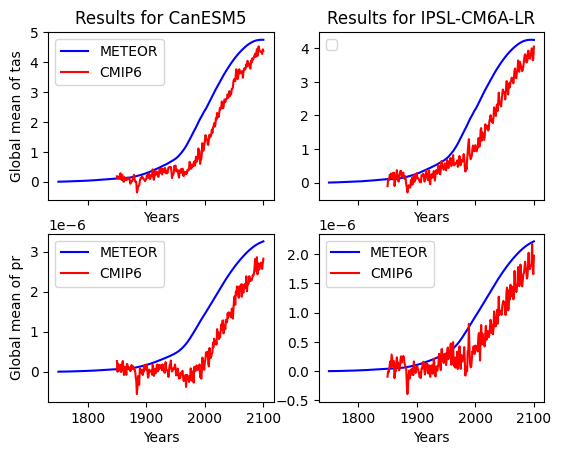

In [23]:
fig, axs = plt.subplots(nrows=len(flds), ncols=len(models), sharex=True)

for i, model in enumerate(models):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(data_pi[i][fld]).values)
        print(zero_val)
        hist_time = prpatt.global_mean(data_hist[i][fld]).values[0]
        #print(f"Variable: {fld} and model {model}: {hist_time}")
        axs[j,i].plot(years_total, prpatt.global_mean(pattern_ssp[i][fld]).values, color="blue", label="METEOR")
        print(model)
        axs[j,i].plot(years_hist[:len(hist_time)], hist_time - zero_val, color="red", label="CMIP6")
        axs[j,i].plot(years_ssp, prpatt.global_mean(data_ssp[i][fld]).values[0] - zero_val, color="red")
        #axs[j,i].set_xlim(left=1850, right=2100)
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Results for {model}")
        if i == 0:
            axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[i,j].legend()
    #print(model_basic_pattern.exp_forc_dict)

In [109]:
patt_ghg=pattern_ssp[0]['tas'].sel(time=slice("1970-06-01", "2010-06-10")).mean('time')
patt_hist=data_hist[0]['tas'].sel(year=slice("1970", "2010")).mean('year')
patt_base=data_pi[0]['tas'].mean('year')
pyrs=pattern_ssp[0]['tas'].time.dt.year.values
mn_aemis=em_data[(em_data.index >= 1990) & (em_data.index <= 2010)]['SO2'].mean()
apat=((patt_hist-patt_base)-patt_ghg)/mn_aemis
em_scl=em_data['SO2'][(em_data.index >= min(pyrs)) & (em_data.index <= max(pyrs))].to_xarray().rename({'Component':'time'})

In [116]:
(em_scl*apat)

<xarray.DataArray (time: 351, ens: 1, lat: 64, lon: 128)> Size: 23MB
array([[[[ 0.02340834,  0.02364706,  0.02385153, ...,  0.02278357,
           0.02278237,  0.02315786],
         [ 0.02147496,  0.02190818,  0.0221943 , ...,  0.02037579,
           0.02076343,  0.02101478],
         [ 0.0210808 ,  0.02175105,  0.02214077, ...,  0.01825341,
           0.0191525 ,  0.02057215],
         ...,
         [-0.11513611, -0.11508768, -0.11382028, ..., -0.11014167,
          -0.11223733, -0.11438784],
         [-0.10808568, -0.10823268, -0.10898398, ..., -0.10951111,
          -0.10853007, -0.10876355],
         [-0.11325351, -0.11332896, -0.11346954, ..., -0.1143103 ,
          -0.11427363, -0.1137944 ]]],


       [[[ 0.02321331,  0.02345004,  0.0236528 , ...,  0.02259374,
           0.02259255,  0.02296491],
         [ 0.02129603,  0.02172564,  0.02200937, ...,  0.02020602,
           0.02059043,  0.02083969],
         [ 0.02090516,  0.02156982,  0.0219563 , ...,  0.01810132,
...
          -0.29192516, -0.29751856],
         [-0.28112689, -0.28150921, -0.28346334, ..., -0.28483438,
          -0.28228272, -0.28289   ],
         [-0.29456823, -0.29476446, -0.2951301 , ..., -0.2973169 ,
          -0.29722151, -0.29597505]]],


       [[[ 0.05989554,  0.06050636,  0.06102953, ...,  0.05829693,
           0.05829385,  0.05925462],
         [ 0.05494854,  0.05605704,  0.05678913, ...,  0.05213607,
           0.05312794,  0.05377108],
         [ 0.05394001,  0.05565498,  0.05665217, ...,  0.04670547,
           0.04900601,  0.0526385 ],
         ...,
         [-0.29460181, -0.29447789, -0.29123496, ..., -0.2818224 ,
          -0.28718461, -0.29268719],
         [-0.27656169, -0.27693781, -0.2788602 , ..., -0.28020898,
          -0.27769876, -0.27829618],
         [-0.28978476, -0.28997781, -0.29033751, ..., -0.2924888 ,
          -0.29239496, -0.29116874]]]])
Coordinates:
  * time     (time) int64 3kB 1850 1851 1852 1853 1854 ... 2197 2198 2199 2200
  * ens      (ens) int64 8B 1
    height   float64 8B 2.0
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2

In [103]:
em_data['SO2'][(em_data.index >= min(pyrs)) & (em_data.index <= max(pyrs))].rename(axis='time')

ValueError: No axis named time for object type Series

In [90]:
em_scl*apat

<xarray.DataArray (Component: 351, ens: 1, lat: 64, lon: 128)> Size: 23MB
array([[[[ 0.02340834,  0.02364706,  0.02385153, ...,  0.02278357,
           0.02278237,  0.02315786],
         [ 0.02147496,  0.02190818,  0.0221943 , ...,  0.02037579,
           0.02076343,  0.02101478],
         [ 0.0210808 ,  0.02175105,  0.02214077, ...,  0.01825341,
           0.0191525 ,  0.02057215],
         ...,
         [-0.11513611, -0.11508768, -0.11382028, ..., -0.11014167,
          -0.11223733, -0.11438784],
         [-0.10808568, -0.10823268, -0.10898398, ..., -0.10951111,
          -0.10853007, -0.10876355],
         [-0.11325351, -0.11332896, -0.11346954, ..., -0.1143103 ,
          -0.11427363, -0.1137944 ]]],


       [[[ 0.02321331,  0.02345004,  0.0236528 , ...,  0.02259374,
           0.02259255,  0.02296491],
         [ 0.02129603,  0.02172564,  0.02200937, ...,  0.02020602,
           0.02059043,  0.02083969],
         [ 0.02090516,  0.02156982,  0.0219563 , ...,  0.01810132,
...
          -0.29192516, -0.29751856],
         [-0.28112689, -0.28150921, -0.28346334, ..., -0.28483438,
          -0.28228272, -0.28289   ],
         [-0.29456823, -0.29476446, -0.2951301 , ..., -0.2973169 ,
          -0.29722151, -0.29597505]]],


       [[[ 0.05989554,  0.06050636,  0.06102953, ...,  0.05829693,
           0.05829385,  0.05925462],
         [ 0.05494854,  0.05605704,  0.05678913, ...,  0.05213607,
           0.05312794,  0.05377108],
         [ 0.05394001,  0.05565498,  0.05665217, ...,  0.04670547,
           0.04900601,  0.0526385 ],
         ...,
         [-0.29460181, -0.29447789, -0.29123496, ..., -0.2818224 ,
          -0.28718461, -0.29268719],
         [-0.27656169, -0.27693781, -0.2788602 , ..., -0.28020898,
          -0.27769876, -0.27829618],
         [-0.28978476, -0.28997781, -0.29033751, ..., -0.2924888 ,
          -0.29239496, -0.29116874]]]])
Coordinates:
  * Component  (Component) int64 3kB 1850 1851 1852 1853 ... 2197 2198 2199 2200
  * ens        (ens) int64 8B 1
    height     float64 8B 2.0
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2

In [77]:
min()

1850

In [86]:
pattern_ssp[0]['tas']

<xarray.DataArray (time: 351, lat: 64, lon: 128)> Size: 23MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[2.59308627e-04, 2.60891996e-04, 2.62435354e-04, ...,
         2.55291081e-04, 2.56524226e-04, 2.57842981e-04],
        [2.61243827e-04, 2.64487731e-04, 2.67372569e-04, ...,
         2.50694064e-04, 2.54210639e-04, 2.57864569e-04],
        [2.66889471e-04, 2.71612527e-04, 2.74819123e-04, ...,
         2.48654995e-04, 2.54678473e-04, 2.60989131e-04],
...
        [1.47580633e+01, 1.45972210e+01, 1.44532675e+01, ...,
         1.52483670e+01, 1.50920609e+01, 1.49256860e+01],
        [1.53866430e+01, 1.52810648e+01, 1.51841279e+01, ...,
         1.57282624e+01, 1.56111499e+01, 1.54966566e+01],
        [1.55104016e+01, 1.54845417e+01, 1.54609293e+01, ...,
         1.55898820e+01, 1.55624878e+01, 1.55362041e+01]],

       [[6.74343489e+00, 6.76908987e+00, 6.79448497e+00, ...,
         6.66158580e+00, 6.68922831e+00, 6.71693925e+00],
        [6.79605084e+00, 6.84938352e+00, 6.89080556e+00, ...,
         6.57990902e+00, 6.66221463e+00, 6.73293329e+00],
        [6.95788833e+00, 7.03502194e+00, 7.08337523e+00, ...,
         6.55612482e+00, 6.70944970e+00, 6.84498666e+00],
        ...,
        [1.47526815e+01, 1.45909533e+01, 1.44461340e+01, ...,
         1.52455921e+01, 1.50884190e+01, 1.49211788e+01],
        [1.53814467e+01, 1.52754926e+01, 1.51781790e+01, ...,
         1.57242081e+01, 1.56067325e+01, 1.54918365e+01],
        [1.55052069e+01, 1.54792638e+01, 1.54555770e+01, ...,
         1.55849514e+01, 1.55574577e+01, 1.55310984e+01]]])
Coordinates:
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * time     (time) datetime64[ns] 3kB 1850-01-01 1851-01-01 ... 2200-01-01

In [79]:
em_data['SO2']

Component
1750    1.222464
1751    1.206598
1752    1.200955
1753    1.207757
1754    1.233495
          ...   
2496    1.017462
2497    1.017462
2498    1.017462
2499    1.017462
2500    1.017462
Name: SO2, Length: 751, dtype: float64

In [80]:
pattern_ssp

[{'pr': <xarray.DataArray (time: 351, lat: 64, lon: 128)> Size: 23MB
  array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          ...,
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
  
         [[1.56800200e-11, 1.55748620e-11, 1.53501259e-11, ...,
           1.60181642e-11, 1.60131042e-11, 1.59078202e-11],
          [1.22546437e-11, 1.18661521e-11, 1